# Logistic Regression Project (Predict Ad click)

In this notebook we will use `Logistic Regression` to indicating whether or not a particular internet user clicked on an Advertisement. We will try to create a model that will predict whether or not they will click on an ad based off the features of that user.

This data set contains the following features:

* '`Daily Time Spent on Site`': consumer time on site in minutes
* '`Age`': customer age in years
* '`Area Income`': Avg. Income of geographical area of consumer
* '`Daily Internet Usage`': Avg. minutes a day consumer is on the internet
* '`Ad Topic Line`': Headline of the advertisement
* '`City`': City of consumer
* '`Male`': Whether or not consumer was male
* '`Country`': Country of consumer
* '`Timestamp`': Time at which consumer clicked on Ad or closed window
* '`Clicked on Ad`': 0 or 1 indicated clicking on Ad

TRADUCCIÓN:

* **`Daily Time Spent on Site`**: tiempo diario que el consumidor pasa en el sitio (en minutos)
* **`Age`**: edad del cliente (en años)
* **`Area Income`**: ingreso promedio del área geográfica del consumidor
* **`Daily Internet Usage`**: minutos promedio al día que el consumidor usa internet
* **`Ad Topic Line`**: encabezado del anuncio
* **`City`**: ciudad del consumidor
* **`Male`**: indica si el consumidor es hombre
* **`Country`**: país del consumidor
* **`Timestamp`**: momento en el que el consumidor hizo clic en el anuncio o cerró la ventana
* **`Clicked on Ad`**: 0 o 1 indicando si hizo clic en el anuncio


In [53]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
%matplotlib inline

## Get the Data

In [54]:
df_click = pd.read_csv("data/advertising.csv", sep=",")
df_click.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


# 1. Exploratory Data Analysis

In [55]:
df_click.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [56]:
df_click.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [57]:
df_click.groupby("Country")["Country"].count()

Country
Afghanistan          8
Albania              7
Algeria              6
American Samoa       5
Andorra              2
                    ..
Wallis and Futuna    4
Western Sahara       7
Yemen                3
Zambia               4
Zimbabwe             6
Name: Country, Length: 237, dtype: int64

In [58]:
df_click['Clicked on Ad'].value_counts(normalize=True)

Clicked on Ad
0    0.5
1    0.5
Name: proportion, dtype: float64

In [60]:
print(df_click.groupby('Clicked on Ad').size())

Clicked on Ad
0    500
1    500
dtype: int64


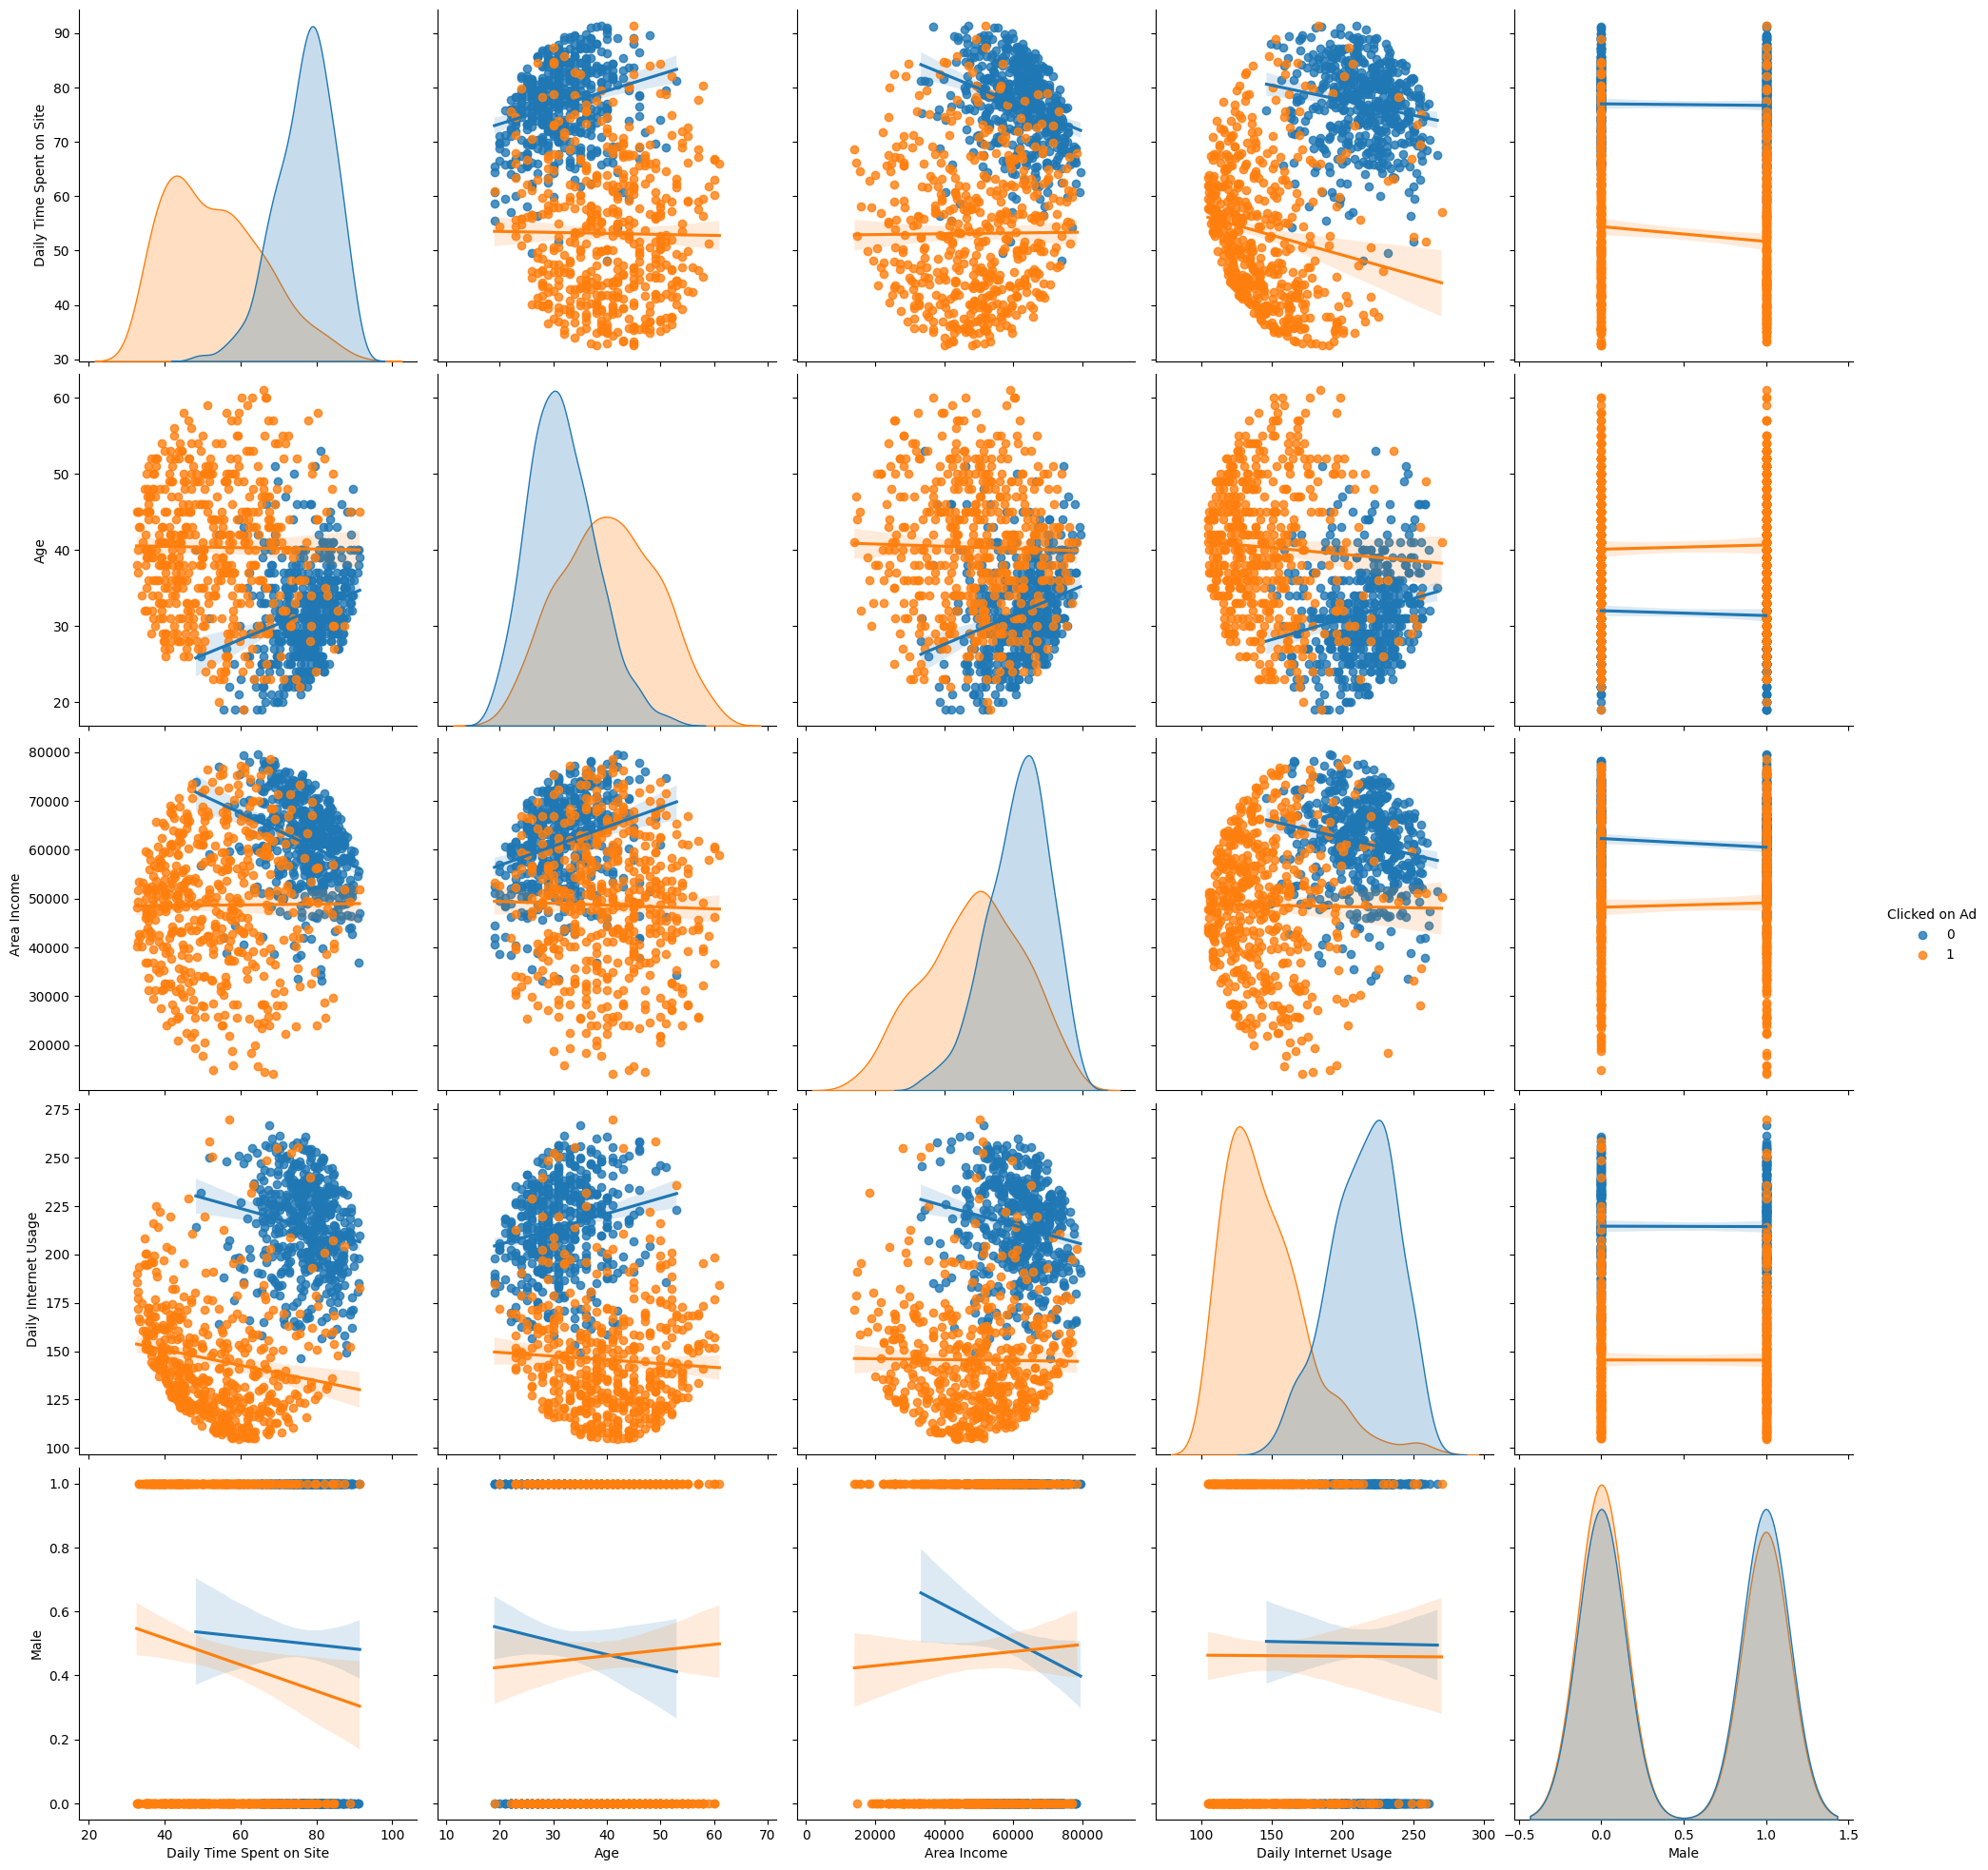

In [61]:
sns.pairplot(df_click.dropna(),
            hue='Clicked on Ad',
            height=4,
            vars=["Daily Time Spent on Site", 
                  "Age",
                  "Area Income",
                  "Daily Internet Usage", 
                  "Male"],
            kind='reg');

In [62]:
df_click_copy = df_click.copy()
df_click_copy.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


<Axes: >

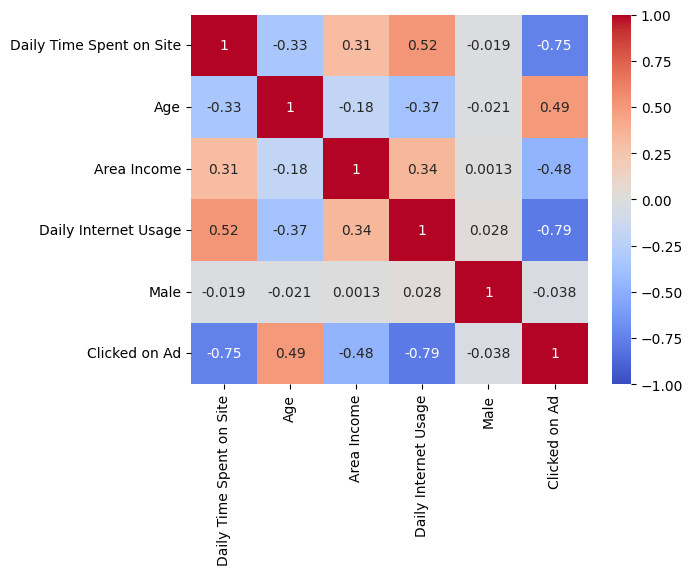

In [63]:
sns.heatmap(df_click.corr(numeric_only=True), annot=True, vmin=-1, cmap="coolwarm")

# 2. Prepare Data for Logistic Regression



#### 2. Train test split


In [64]:
df_click_copy = df_click_copy.drop(["Ad Topic Line", "City", "Country", "Timestamp"], axis=1)
df_click_copy

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0
...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,1,1
996,51.30,45,67782.17,134.42,1,1
997,51.63,51,42415.72,120.37,1,1
998,55.55,19,41920.79,187.95,0,0


In [65]:
X = df_click_copy.drop("Clicked on Ad", axis=1)
X

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male
0,68.95,35,61833.90,256.09,0
1,80.23,31,68441.85,193.77,1
2,69.47,26,59785.94,236.50,0
3,74.15,29,54806.18,245.89,1
4,68.37,35,73889.99,225.58,0
...,...,...,...,...,...
995,72.97,30,71384.57,208.58,1
996,51.30,45,67782.17,134.42,1
997,51.63,51,42415.72,120.37,1
998,55.55,19,41920.79,187.95,0


In [66]:
Y = df_click_copy["Clicked on Ad"]
Y

0      0
1      0
2      0
3      0
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Clicked on Ad, Length: 1000, dtype: int64

In [67]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.20, random_state=11)


#### 3. StandardScaler()


In [74]:
st = StandardScaler()
st.fit(X_train)

X_train_st = st.transform(X_train)
X_test_st = st.transform(X_test)

# 3. Implement a Logistic Regression in Scikit-Learn and predict.

In [77]:
click_model_lr = LogisticRegression(max_iter=1000)
click_model_lr.fit(X_train_st, Y_train)
pred = click_model_lr.predict(X_test_st)

# 4. Evaluation


#### 0. Accuracy

In [78]:
print("Accuracy:", accuracy_score(Y_test, pred))

Accuracy: 0.98



#### 1. Confusion Matrix


<Axes: >

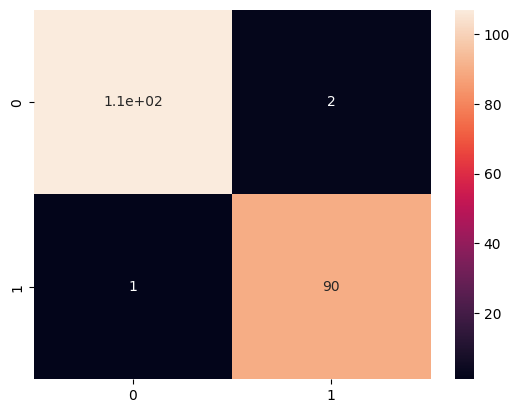

In [71]:
c_matrix = confusion_matrix(Y_test, pred)
sns.heatmap(c_matrix, annot=True)

1.1e+02 = 110


#### 2. Precision


Cuántos son realmente 1s, de todos los que ha predicho como 1s

TP / (TP + FP)

In [79]:
from sklearn.metrics import precision_score

precision_score(Y_test, pred)

0.978021978021978



#### 3. Recall


Cuántos has predicho como 1, de los que realmente eran 1s

TP / (TP + FN)

In [80]:
from sklearn.metrics import recall_score

recall_score(Y_test, pred)

0.978021978021978



#### 4. F1 Score


2 * p * r / (r + p)

In [81]:
from sklearn.metrics import f1_score

f1_score(Y_test, pred)

0.978021978021978



#### 5. ROC curve

In [91]:
from sklearn.metrics import roc_curve, roc_auc_score

logreg = LogisticRegression()
logreg.fit(X_train_st, Y_train)
pred_prob = logreg.predict_proba(X_test_st)[:, 1] 
fpr, tpr, thresholds = roc_curve(Y_test, pred_prob)

auc = roc_auc_score(Y_test, pred_prob)
print("AUC: ", auc)

AUC:  0.9993951003125315


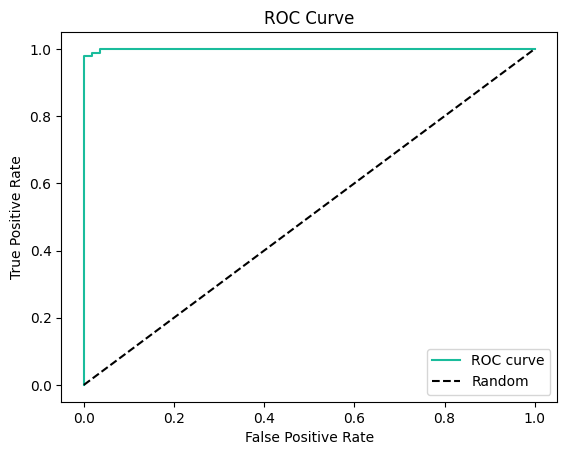

In [90]:
plt.plot(fpr, tpr, label='ROC curve', color="#1abc9c")
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()



#### 6. P-R curve

Average Precision (AP): 0.9992984132572234


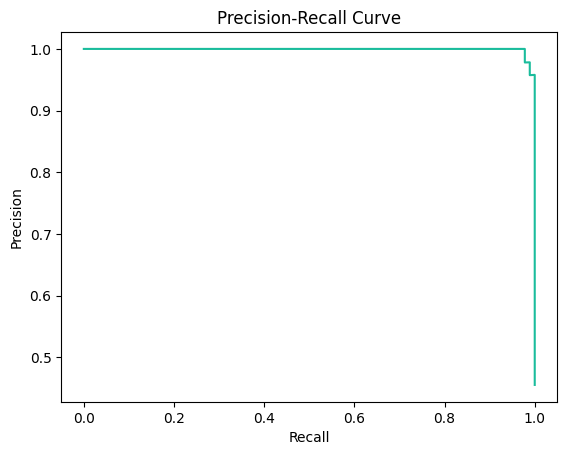

In [95]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(Y_test, pred_prob)

ap = average_precision_score(Y_test, pred_prob)
print("Average Precision (AP):", ap)

import matplotlib.pyplot as plt
plt.plot(recall, precision, color='#1abc9c')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()